# Naturutbygging i Norge (Dynamic World, overgangslogikk)

## Metode (Google Earth Engine)
Denne analysen bygger på *Dynamic World* aggregert for sommerperioden (1. juni–1. september) i Google Earth Engine. Hovedstegene er:

1. **Sommerfilter**: Henter Dynamic World-bilder innenfor tidsvinduet for hvert år (2023, 2024, 2025).
2. **Fast analysegrid**: Downsampler sannsynlighet til et fast rutenett (30 m) før års-gjennomsnitt beregnes.
3. **Terskling til binær bygd/ikke-bygd**: Piksel klassifiseres som *bygd* dersom gjennomsnittlig built-sannsynlighet ≥ terskel (70%).
4. **Overgangslogikk (transition)**: Ny utbygging måles som overganger **ikke-bygd → bygd** mellom år (GAIN). Vi beregner også LOSS (bygd → ikke-bygd) og NET = GAIN − LOSS som en kvalitetssjekk.
5. **Aggregering per kommune **: Pikselareal summeres innenfor kommune-ID-rasteret, og eksporteres som CSV.

**Viktig tolkning:** `gain_km2_*` er et mer robust mål på *nyklassifisert utbygging* enn differanse i total built-bestand, fordi det eksplisitt teller overganger. Altså tar ikke rapporten for seg areal som har blitt gjort om fra bygd til natur (vanligvis restaurering).


## 1) Last inn data
Notebooken forventer tre filer i samme mappe som notebooken:

- `built_per_kid_2023_2025_summer_transitions_*.csv` (output fra GEE med overgangslogikk)
- `robek_listen.csv` (ROBEK sommeren 2023; kolonner: `kommunenr, kommune, fylke`)
- `kommunenummer.csv` (Kartverket/Geonorge; semikolon-separert; kolonner bl.a. `Navn;Kodeverdi;Status`)

Vi kobler deretter på kommunenavn og en ROBEK-indikator (1/0).


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
from matplotlib.colors import PowerNorm
import geopandas as gpd

sns.set_context('notebook')

# ---- Filnavn (auto-finn hvis du ikke vil hardkode) ----
DATA_FILE = 'built_per_kid_2023_2025_summer_transitions_30m_south_terskel07.csv'  # valgfritt navn
ROBEK_FILE = 'robek_listen.csv'
KOMMUNE_FILE = 'kommunenummer.csv'

# Finn transitions-csv automatisk hvis DATA_FILE ikke finnes
if not Path(DATA_FILE).exists():
    matches = sorted(glob.glob('built_per_kid_2023_2025_summer_transitions_*.csv'))
    if len(matches) == 0:
        raise FileNotFoundError('Fant ingen transitions-CSV. Legg filen i samme mappe, eller oppdater DATA_FILE.')
    DATA_FILE = matches[0]

df = pd.read_csv(DATA_FILE)

# ROBEK: kommunenr, kommune, fylke  -> robek=1
robek = pd.read_csv(ROBEK_FILE)
robek = robek.rename(columns={'kommunenr': 'kid'})
robek['kid'] = pd.to_numeric(robek['kid'], errors='coerce').astype('Int64')
robek = robek.dropna(subset=['kid'])
robek['kid'] = robek['kid'].astype(int)
robek['robek'] = 1

# Kommunenummer: semikolon-separert, Navn;Kodeverdi;Status;...
kommuner = pd.read_csv(KOMMUNE_FILE, sep=';', dtype=str)
kommuner = kommuner.rename(columns={'Navn': 'kommune', 'Kodeverdi': 'kid'})
kommuner['kid'] = kommuner['kid'].str.strip()
kommuner['kid'] = pd.to_numeric(kommuner['kid'], errors='coerce').astype('Int64')
kommuner = kommuner.dropna(subset=['kid'])
kommuner['kid'] = kommuner['kid'].astype(int)

# Ta helst med 'Gyldig' kommunenavn (men behold fallback hvis noen mangler)
kommuner_valid = kommuner.copy()
if 'Status' in kommuner_valid.columns:
    kommuner_valid = kommuner_valid[kommuner_valid['Status'].str.strip().eq('Gyldig')]

# Merge: navn + ROBEK
df['kid'] = pd.to_numeric(df['kid'], errors='coerce').astype('Int64')
df = df.dropna(subset=['kid']).copy()
df['kid'] = df['kid'].astype(int)

df = df.merge(kommuner_valid[['kid', 'kommune']].drop_duplicates('kid'), on='kid', how='left')
# fallback til alle kommuner hvis noen mangler
missing = df['kommune'].isna()
if missing.any():
    df = df.merge(kommuner[['kid','kommune']].drop_duplicates('kid'), on='kid', how='left', suffixes=('', '_fallback'))
    df['kommune'] = df['kommune'].fillna(df['kommune_fallback'])
    df = df.drop(columns=[c for c in ['kommune_fallback'] if c in df.columns])

df = df.merge(robek[['kid','robek']], on='kid', how='left')
df['robek'] = df['robek'].fillna(0).astype(int)

# Sjekk at forventede kolonner finnes
expected = [
    'built_km2_2023','built_km2_2024','built_km2_2025',
    'gain_km2_23_24','gain_km2_24_25','gain_km2_23_25',
    'loss_km2_23_24','loss_km2_24_25','loss_km2_23_25',
    'net_km2_23_24','net_km2_24_25','net_km2_23_25'
]
missing_cols = [c for c in expected if c not in df.columns]
if missing_cols:
    raise ValueError('Mangler forventede kolonner i transitions-CSV: ' + ', '.join(missing_cols))

# For lesbarhet
df['kommune'] = df['kommune'].fillna(df['kid'].astype(str))
df.head()

,kid,built_km2_2023,built_km2_2024,built_km2_2025,gain_km2_23_24,loss_km2_23_24,net_km2_23_24,gain_km2_24_25,loss_km2_24_25,net_km2_24_25,gain_km2_23_25,loss_km2_23_25,net_km2_23_25,delta_km2_23_24,delta_km2_24_25,delta_km2_23_25,kommune,robek
0,301,68.887600,52.284463,55.023320,3.592601,20.195738,-16.603137,9.088278,6.349421,2.738856,4.026120,17.890400,-13.864280,3.592601,9.088278,4.026120,Oslo,0
1,1101,3.204682,3.154580,2.815525,0.581534,0.631636,-0.050101,0.458074,0.797129,-0.339055,0.404398,0.793554,-0.389156,0.581534,0.458074,0.404398,Eigersund,0
2,1103,26.953119,21.302402,22.668129,1.716289,7.367006,-5.650717,5.067678,3.701952,1.365727,1.118297,5.403288,-4.284990,1.716289,5.067678,1.118297,Stavanger,0
3,1106,9.191496,9.927316,9.197369,1.514100,0.778279,0.735821,0.704528,1.434475,-0.729947,1.306872,1.300998,0.005874,1.514100,0.704528,1.306872,Haugesund,0
4,1108,17.278368,16.117616,12.651304,1.223157,2.383909,-1.160752,1.242061,4.708372,-3.466312,0.585694,5.212757,-4.627063,1.223157,1.242061,0.585694,Sandnes,0


## 2) Nasjonal tidsserie: akkumulert *ny utbygging* (GAIN)
Vi bruker `gain_km2_23_24` og `gain_km2_24_25` som årlige tilskudd (ny utbygging via overganger). Deretter lager vi en enkel akkumulert kurve.

Jeg tar utgangspunt i den estimerte feilraten fra NRK, og ganger derfor akkumulert naturutbygging med (1-feilrate) som ligger på 0.18 (18% false positive).

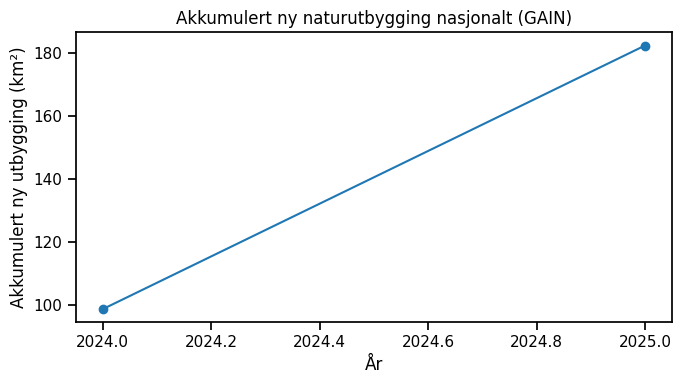

Utbygging per år: 91.11769593668514 km^2


In [8]:
feilrate_nrk = 0.18

national_gain = pd.Series({
    2024: df['gain_km2_23_24'].sum()*(1-feilrate_nrk),
    2025: df['gain_km2_24_25'].sum()*(1-feilrate_nrk),
}).sort_index()

national_cum = national_gain.cumsum()

plt.figure(figsize=(7,4))
national_cum.plot(marker='o')
plt.ylabel('Akkumulert ny utbygging (km²)')
plt.xlabel('År')
plt.title('Akkumulert ny naturutbygging nasjonalt (GAIN)')
plt.tight_layout()
plt.show()


print("Utbygging per år:" ,(df['gain_km2_23_24'].sum()*(1-feilrate_nrk) + df['gain_km2_24_25'].sum()*(1-feilrate_nrk))/2, "km^2")

## 3) Heat map: utbygging per kommune (sensitiv fargeskala)
Heat mapet viser `gain_km2_23_25` per kommune. For å få frem flere nyanser bruker vi en *PowerNorm* (gamma < 1) som øker kontrasten i lave og middels verdier uten log-transformasjon.

C:\Users\ktann\AppData\Local\Temp\ipykernel_7216\1435550510.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(cmap),


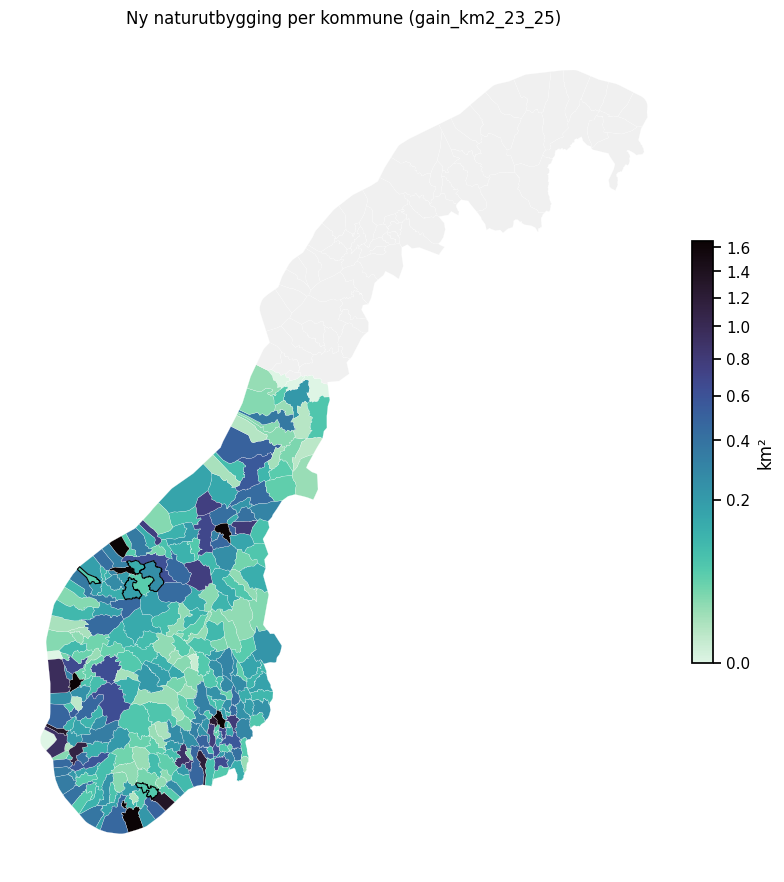

In [9]:
import geopandas as gpd
# -----------------------------
# 1) Velg variabelen du vil kartlegge
# -----------------------------
VALUE_COL = "gain_km2_23_25"   # ny utbygging 2023–2025 (GAIN)
# VALUE_COL = "gain_km2_23_24"
# VALUE_COL = "gain_km2_24_25"
# VALUE_COL = "net_km2_23_25"   # kan være negativ (se divergerende logikk under)

# -----------------------------
# 2) Last kommunegrenser (din fil)
# -----------------------------
BOUNDARY_FILE = "Basisdata_0000_Norge_25833_Kommune_GeoJSON.geojson"  # <-- endre til din fil
gdf = gpd.read_file(BOUNDARY_FILE)

# -----------------------------
# 3) Bruk riktige kolonner fra geofila
# -----------------------------
# Du har 'kommunenummer' i fila di (kolonnelista viser dette).
gdf["kid"] = pd.to_numeric(gdf["kommunenummer"], errors="coerce").astype("Int64")
gdf = gdf.dropna(subset=["kid"]).copy()
gdf["kid"] = gdf["kid"].astype(int)

# (valgfritt) behold navnet fra geofila som fallback
if "kommunenavn" in gdf.columns:
    gdf["kommune_geo"] = gdf["kommunenavn"]
elif "administrativenhetnavn" in gdf.columns:
    gdf["kommune_geo"] = gdf["administrativenhetnavn"]
else:
    gdf["kommune_geo"] = None

# -----------------------------
# 4) Slå sammen med analysedata (df må allerede være lastet i notebooken)
# -----------------------------
# df kommer fra forrige celler: inneholder kid, kommune (fra kommunenummer.csv), robek, VALUE_COL
map_df = gdf.merge(df[["kid", "kommune", "robek", VALUE_COL]], on="kid", how="left")

# fallback kommunenavn hvis df ikke har navn
map_df["kommune"] = map_df["kommune"].fillna(map_df["kommune_geo"]).fillna(map_df["kid"].astype(str))

# -----------------------------
# 5) Sensitiv fargeskala (uten log) + robust vmax
# -----------------------------
vals = map_df[VALUE_COL].fillna(0).to_numpy()

# Hvis variabelen kan være negativ (f.eks. net_*), bruk divergerende kart
if np.nanmin(vals) < 0:
    vmax = np.nanpercentile(np.abs(vals), 99)  # robust mot outliers
    cmap = "coolwarm"
    norm = None
    vmin, vmax = -vmax, vmax
else:
    vmin = 0
    vmax = np.nanpercentile(vals, 99)  # robust øvre grense
    # gamma < 1 => mer sensitiv i små/middels verdier (uten log-transformasjon)
    norm = PowerNorm(gamma=0.45, vmin=vmin, vmax=vmax)
    cmap = "mako_r"
    vmin, vmax = None, None  # norm styrer dette

# -----------------------------
# 6) Plot kart
# -----------------------------
fig, ax = plt.subplots(1, 1, figsize=(8, 10))

map_df.plot(
    column=VALUE_COL,
    ax=ax,
    cmap=cmap,
    norm=norm,
    vmin=vmin,
    vmax=vmax,
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "#f0f0f0", "label": "Mangler data"}
)


map_df[map_df["robek"] == 1].plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.8
)


ax.set_axis_off()
ax.set_title(f"Ny naturutbygging per kommune ({VALUE_COL})", fontsize=12)

# Colorbar
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.get_cmap(cmap),
    norm=norm if norm else plt.Normalize(vmin=vmin, vmax=vmax)
)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("km²", rotation=90)

plt.tight_layout()
plt.show()

## 4) ROBEK vs. øvrige kommuner
Vi sammenligner gjennomsnittlig ny utbygging per kommune (`gain_km2_23_25`) mellom ROBEK-kommuner og øvrige kommuner. Tabellen viser også antall kommuner og median for robusthet.

In [10]:
comp = (df.groupby('robek')
          .agg(
              n=('kid','nunique'),
              mean_gain_km2=('gain_km2_23_25','mean'),
              median_gain_km2=('gain_km2_23_25','median'),
              sum_gain_km2=('gain_km2_23_25','sum')
          )
          .reset_index())

comp['gruppe'] = comp['robek'].map({0:'Ikke ROBEK', 1:'ROBEK'})
comp = comp[['gruppe','n','mean_gain_km2','median_gain_km2','sum_gain_km2']]
comp = comp.sort_values('gruppe')

comp.style.format({
    'mean_gain_km2': '{:.3f}',
    'median_gain_km2': '{:.3f}',
    'sum_gain_km2': '{:.3f}'
})

,gruppe,n,mean_gain_km2,median_gain_km2,sum_gain_km2
0,Ikke ROBEK,285,0.269,0.122,76.581
1,ROBEK,5,0.138,0.132,0.688


## 5) Toppliste: Top 20 kommuner etter ny utbygging (2023–2025)
Topplisten rangerer kommuner etter `gain_km2_23_25`. ROBEK-status er inkludert.

In [11]:
top20 = (df[['kid','kommune','robek','gain_km2_23_25']]
         .sort_values('gain_km2_23_25', ascending=False)
         .head(20)
         .reset_index(drop=True))

top20['robek'] = top20['robek'].map({0:'', 1:'ROBEK'})

top20.style.format({
    'gain_km2_23_25': '{:.3f}',
})

,kid,kommune,robek,gain_km2_23_25
0,5001,Trondheim – Tråante,,8.352
1,301,Oslo,,4.026
2,4204,Kristiansand,,1.889
3,4601,Bergen,,1.666
4,1508,Ålesund,,1.645
5,4203,Arendal,,1.332
6,1106,Haugesund,,1.307
7,3201,Bærum,,1.265
8,3907,Sandefjord,,1.198
9,1103,Stavanger,,1.118


## 6) Fordeling: ny utbygging per kommune
Histogrammet viser fordelingen av `gain_km2_23_25` på tvers av kommuner.

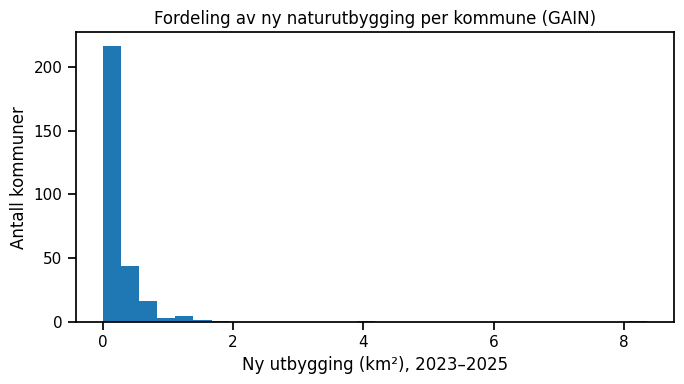

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df['gain_km2_23_25'], bins=30)
plt.xlabel('Ny utbygging (km²), 2023–2025')
plt.ylabel('Antall kommuner')
plt.title('Fordeling av ny naturutbygging per kommune (GAIN)')
plt.tight_layout()
plt.show()

## 8) Sentralitetsindeks

Gjennomsnittlig utbygging per sentralitetsklasse

,sentralitet_klasse_2023,n,mean_nedbygging_km2_periode,median_nedbygging_km2_periode,mean_nedbygging_km2_per_aar,sum_nedbygging_km2_periode
0,1,5,1.255,0.800,0.627,6.274
1,2,21,0.848,0.448,0.424,17.802
2,3,52,0.399,0.250,0.199,20.728
3,4,58,0.256,0.193,0.128,14.846
4,5,91,0.153,0.102,0.077,13.929
5,6,63,0.059,0.025,0.029,3.690


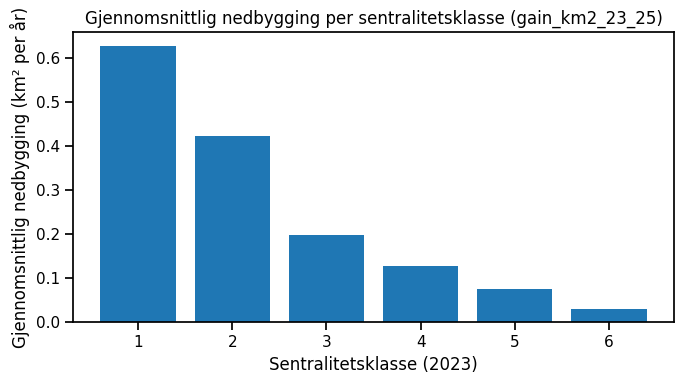

Andel kommuner uten sentralitetsklasse: 0.0%


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Fil ---
CENTRALITY_FILE = "sentralitet 2023-2024 kommuner.xlsx"

# --- Velg hva du mener med "nedbygging" (standard = ny utbygging 23–25) ---
METRIC_COL = "gain_km2_23_25"   # evt. "gain_km2_23_24" eller "gain_km2_24_25"

# 1) Les sentralitet (Excel)
sent = pd.read_excel(CENTRALITY_FILE, engine="openpyxl")
sent.columns = sent.columns.str.strip()

# Forventede kolonner: 'knr 2024', 'Kommune 2024', 'Indeks 2023', 'Klasse 2023', 'Intervall'
# Gjør robust mapping + rydd datatyper
sent = sent.rename(columns={
    "knr 2024": "kid",
    "Kommune 2024": "kommune_sent",
    "Indeks 2023": "sentralitet_indeks_2023",
    "Klasse 2023": "sentralitet_klasse_2023",
    "Intervall": "sentralitet_intervall"
})

sent["kid"] = pd.to_numeric(sent["kid"], errors="coerce").astype("Int64")
sent = sent.dropna(subset=["kid"]).copy()
sent["kid"] = sent["kid"].astype(int)

sent["sentralitet_klasse_2023"] = pd.to_numeric(
    sent["sentralitet_klasse_2023"], errors="coerce"
).astype("Int64")

# 2) Merge med analysedata (df må allerede finnes fra tidligere celler)
df2 = df.merge(
    sent[["kid", "sentralitet_klasse_2023", "sentralitet_indeks_2023", "sentralitet_intervall"]],
    on="kid",
    how="left"
)

# 3) Definer "nedbygging" som valgt metrikk
# Hvis METRIC_COL = gain_km2_23_25 er dette for perioden 2023–2025 (2 år)
df2["nedbygging_km2_periode"] = df2[METRIC_COL]

# Årlig rate (kun meningsfull hvis perioden er 2 år: 23–25)
# (For 23–24 eller 24–25 bør du IKKE dele på 2)
if METRIC_COL == "gain_km2_23_25":
    df2["nedbygging_km2_per_aar"] = df2["nedbygging_km2_periode"] / 2
else:
    df2["nedbygging_km2_per_aar"] = df2["nedbygging_km2_periode"]  # 1-årsperiode

# 4) Aggreger: snitt per sentralitetsklasse (1–6)
summary = (
    df2.dropna(subset=["sentralitet_klasse_2023"])
       .groupby("sentralitet_klasse_2023")
       .agg(
            n=("kid", "nunique"),
            mean_nedbygging_km2_periode=("nedbygging_km2_periode", "mean"),
            median_nedbygging_km2_periode=("nedbygging_km2_periode", "median"),
            mean_nedbygging_km2_per_aar=("nedbygging_km2_per_aar", "mean"),
            sum_nedbygging_km2_periode=("nedbygging_km2_periode", "sum"),
       )
       .reset_index()
       .sort_values("sentralitet_klasse_2023")
)

# 5) Vis tabell
display(
    summary.style.format({
        "mean_nedbygging_km2_periode": "{:.3f}",
        "median_nedbygging_km2_periode": "{:.3f}",
        "mean_nedbygging_km2_per_aar": "{:.3f}",
        "sum_nedbygging_km2_periode": "{:.3f}",
    })
)

# 6) Enkel figur: gjennomsnitt per sentralitetsklasse
plt.figure(figsize=(7,4))
plt.bar(
    summary["sentralitet_klasse_2023"].astype(int),
    summary["mean_nedbygging_km2_per_aar"],
)
plt.xlabel("Sentralitetsklasse (2023)")
plt.ylabel("Gjennomsnittlig nedbygging (km² per år)")
plt.title(f"Gjennomsnittlig nedbygging per sentralitetsklasse ({METRIC_COL})")
plt.xticks([1,2,3,4,5,6])
plt.tight_layout()
plt.show()

# (Valgfritt) Sjekk hvor mange kommuner som manglet sentralitet
missing_share = df2["sentralitet_klasse_2023"].isna().mean()
print(f"Andel kommuner uten sentralitetsklasse: {missing_share:.1%}")